In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [9]:
# Load Data
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [10]:
# Encode
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop(columns='Attrition')
y = df['Attrition']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [12]:
pipeline = Pipeline([
  ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

In [13]:
param_grid = {
    'model__n_estimators': [50, 100, 200],      # Number of trees
    'model__learning_rate': [0.01, 0.05, 0.1],  # Step size for each tree
    'model__max_depth': [3, 4, 5],              # Maximum depth of the individual trees
    'model__subsample': [0.8, 1.0]              # Fraction of samples used for fitting trees (prevents overfitting)
}

# 3. Setup StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Setup and Run GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

In [14]:
print("Starting Grid Search for Gradient Boosting...")
grid.fit(X_train, y_train)

# %%
pipeline = grid.best_estimator_

print("Best Parameters Found:")
for param, value in grid.best_params_.items():
    print(f"{param}: {value}")

Starting Grid Search for Gradient Boosting...


/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._v

Best Parameters Found:
model__learning_rate: 0.1
model__max_depth: 5
model__n_estimators: 200
model__subsample: 0.8


In [36]:
threshold = 0.22

# You do not need to call pipeline.fit() here again! 
# grid.best_estimator_ is already fitted on the whole X_train during the final step of GridSearchCV.

# %%
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= threshold).astype(int)

In [37]:
print("\n── Evaluation ──")
print(classification_report(y_test, y_pred))


── Evaluation ──
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       370
           1       0.48      0.41      0.44        71

    accuracy                           0.83       441
   macro avg       0.68      0.66      0.67       441
weighted avg       0.82      0.83      0.83       441



In [38]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC: 0.7794


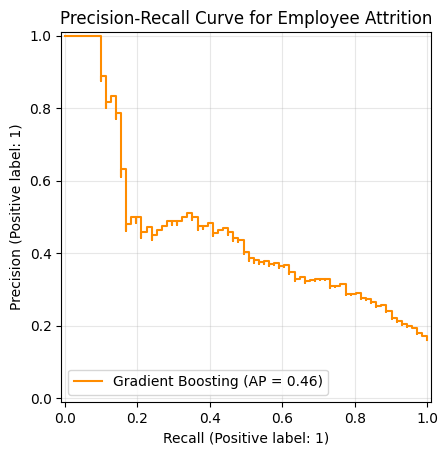

In [29]:
# %%
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Using the y_test and y_proba from your existing code
display = PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_proba, 
    name="Gradient Boosting",
    color="darkorange" # You can customize the line color
)

# Customize the plot
plt.title("Precision-Recall Curve for Employee Attrition")
plt.grid(alpha=0.3) # Adds a light grid for readability
plt.show()